In [1]:
import os 
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [4]:
os.makedirs('../reports/figures',exist_ok=True)

In [6]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [8]:
target_column = 'Outcome'
feature_columns = [col for col in df.columns if col != target_column]

In [ ]:
print('Target Distribution')
print(df[target_column].value_counts())


Target Distribution
Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
print('Target Percentage')
print(df[target_column].value_counts(normalize=True)*100)

Target Percentage
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


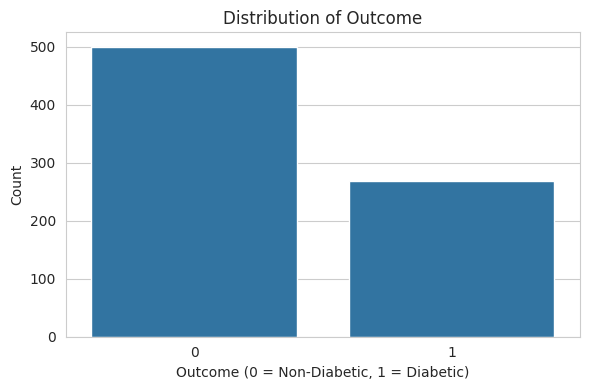

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x =target_column)
plt.title('Distribution of Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/target_distributions.png')

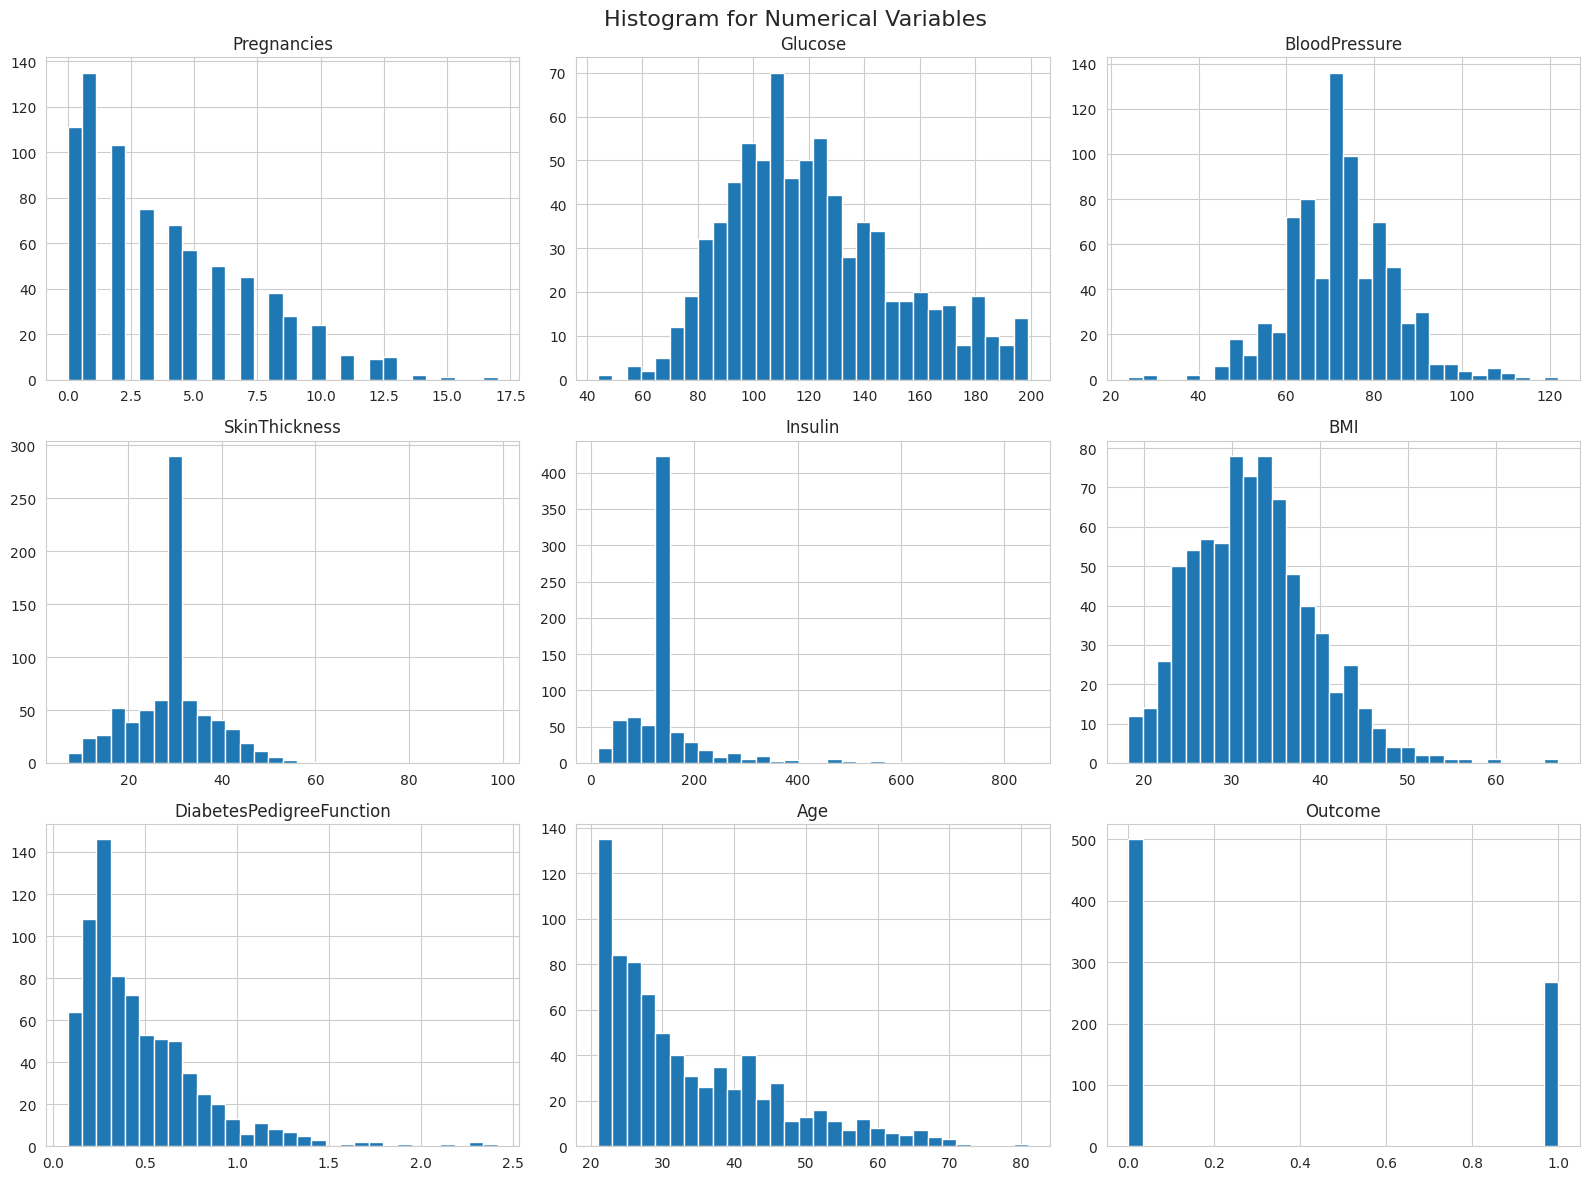

In [31]:
import matplotlib.pyplot as plt

df.hist(
    bins=30,
    figsize=(16, 12)
)
plt.suptitle('Histogram for Numerical Variables',fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/histograms.png')
plt.show()

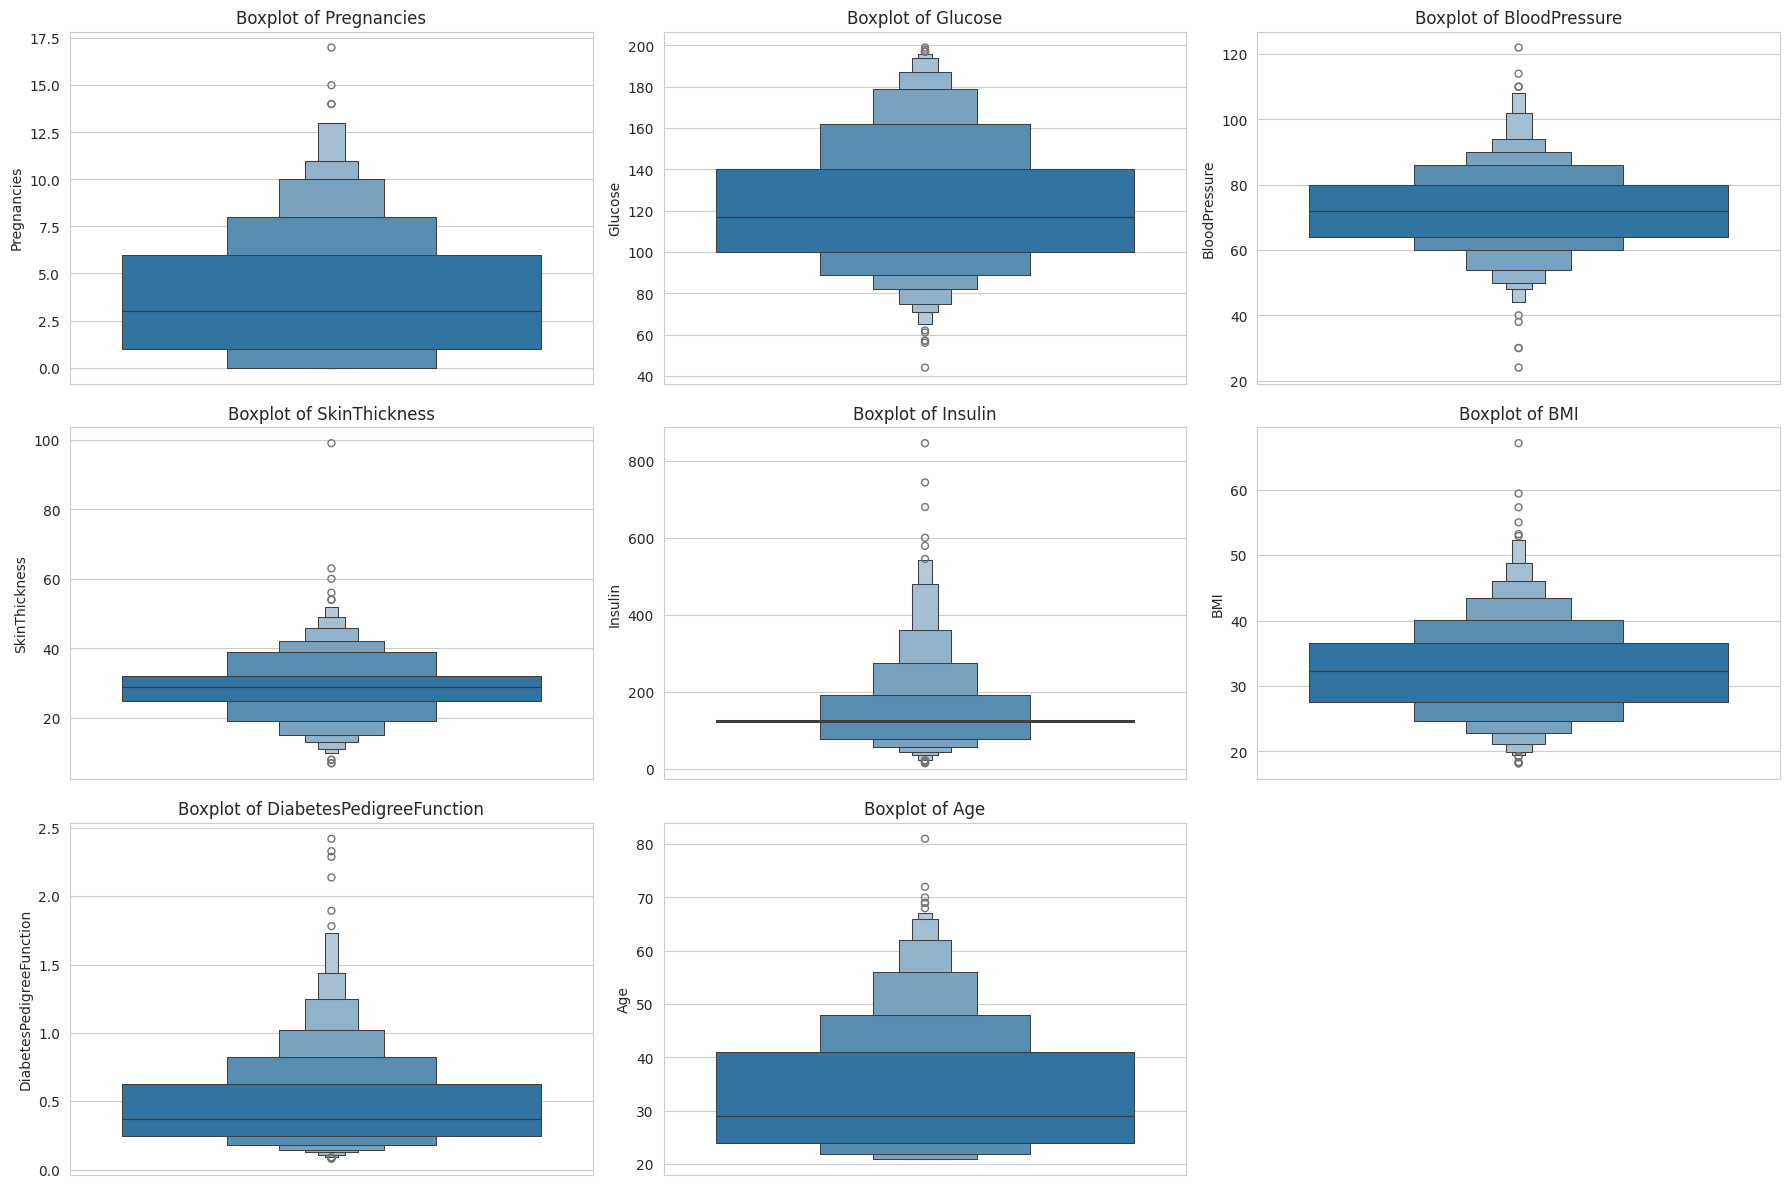

In [40]:
n_features = len(feature_columns)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i ,col in enumerate(feature_columns):
    sns.boxenplot(
        y = df[col],
        ax = axes[i]
    )
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../reports/figures/boxplots.png")
plt.show()

In [59]:
def count_outliers_iqr(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = col[(col < lower) | (col > upper)]

    return len(outliers)


print("Outlier Counts (IQR Method)")
print('=========================================================')

for col in feature_columns:
    outlier_count = count_outliers_iqr(df[col])
    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    print(
        f"{col:<25}"
        f" Count: {outlier_count:<5}"
        f" Percentage: {outlier_percentage:.2f}%"
    )


Outlier Counts (IQR Method)
Pregnancies               Count: 4     Percentage: 0.52%
Glucose                   Count: 0     Percentage: 0.00%
BloodPressure             Count: 14    Percentage: 1.82%
SkinThickness             Count: 87    Percentage: 11.33%
Insulin                   Count: 346   Percentage: 45.05%
BMI                       Count: 8     Percentage: 1.04%
DiabetesPedigreeFunction  Count: 29    Percentage: 3.78%
Age                       Count: 9     Percentage: 1.17%


In [62]:
correlation_matrix = df.corr()
print('correlation Matrix')
display(correlation_matrix)

correlation Matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


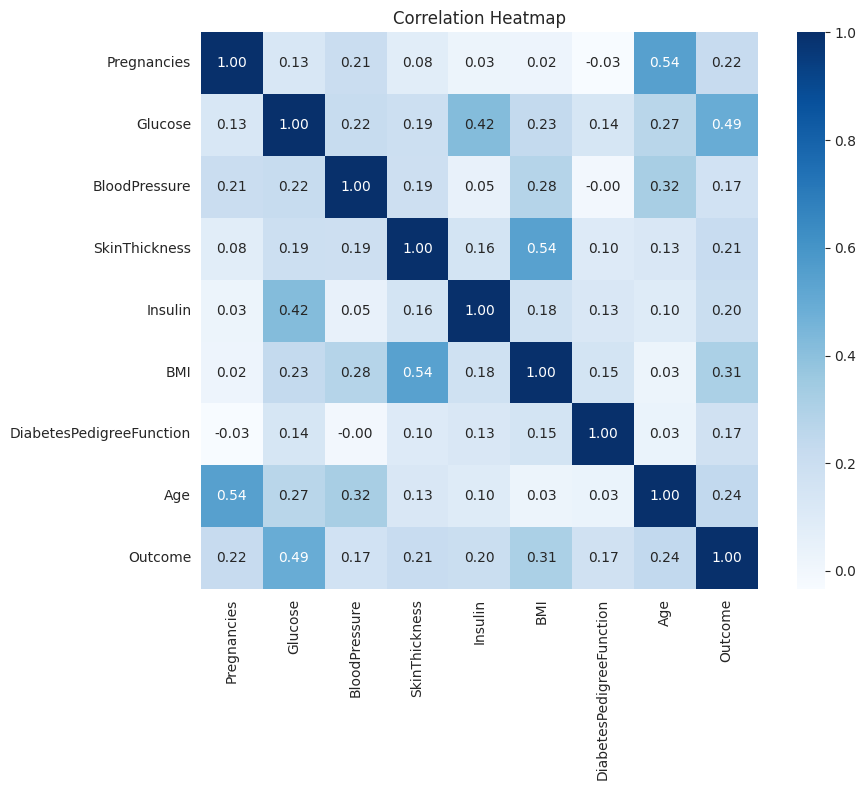

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

Correlation with Target


Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

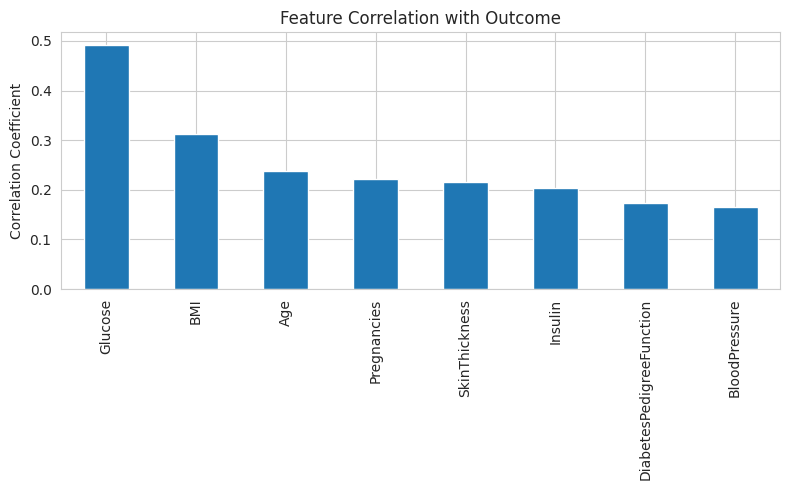

In [70]:
corr_with_target = (
    correlation_matrix[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
)

print("Correlation with Target")
display(corr_with_target)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind="bar")
plt.title("Feature Correlation with Outcome")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.savefig("../reports/figures/feature_correlation_with_target.png")
plt.show()

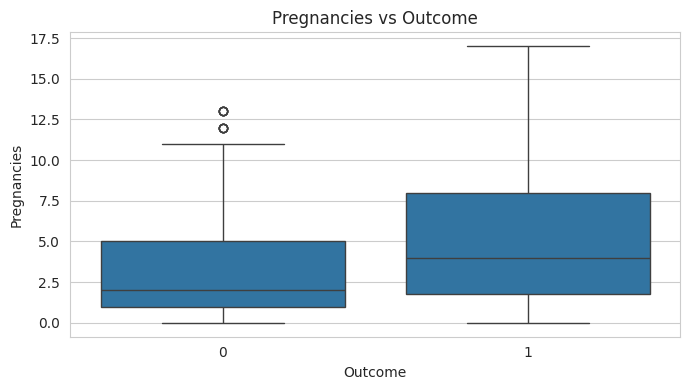

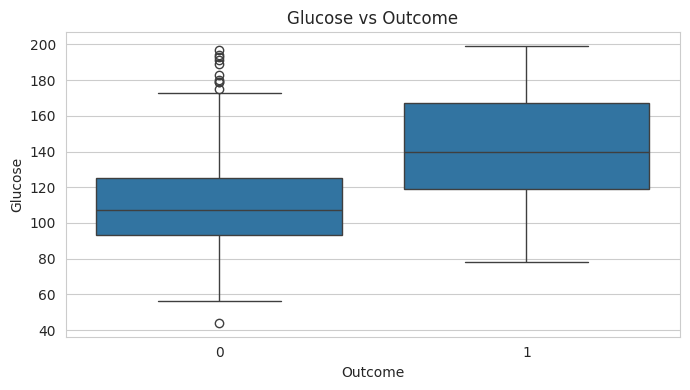

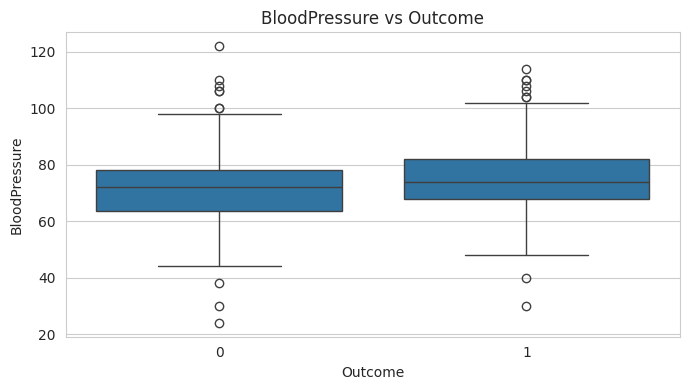

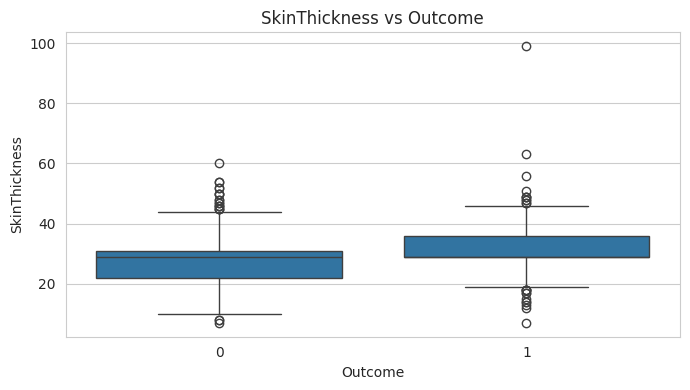

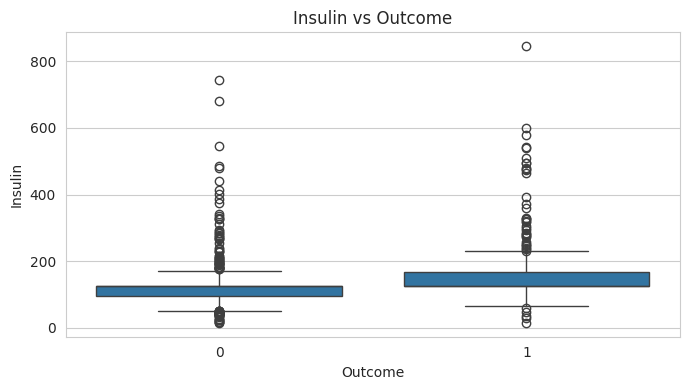

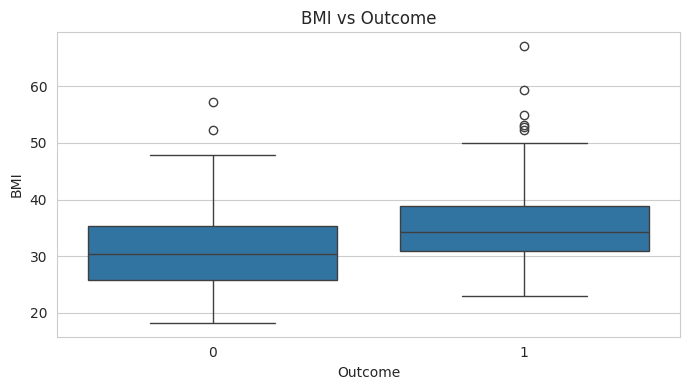

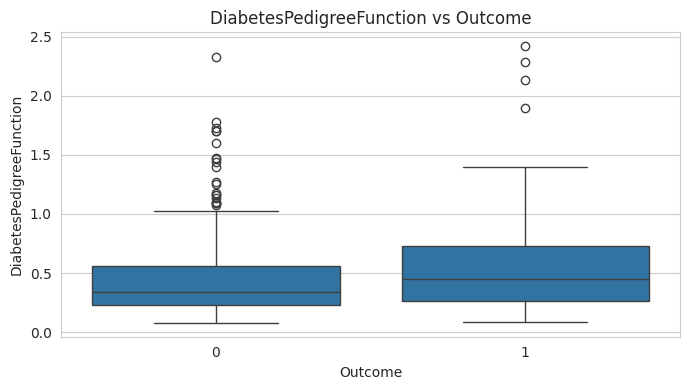

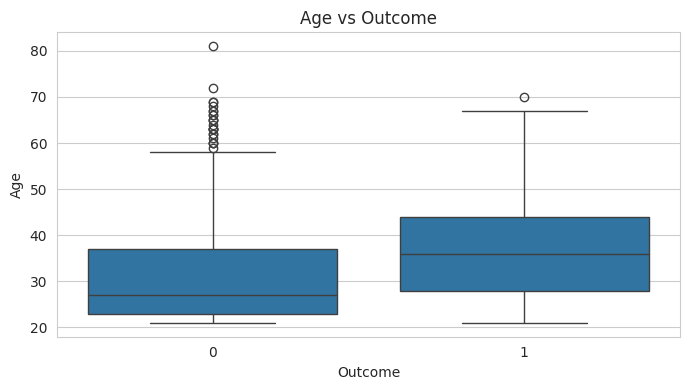

In [71]:
for col in feature_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x=target_column,
        y=col
    )
    plt.title(f"{col} vs Outcome")
    plt.tight_layout()
    plt.savefig(
        f"../reports/figures/{col}_vs_target.png"
    )
    plt.show()

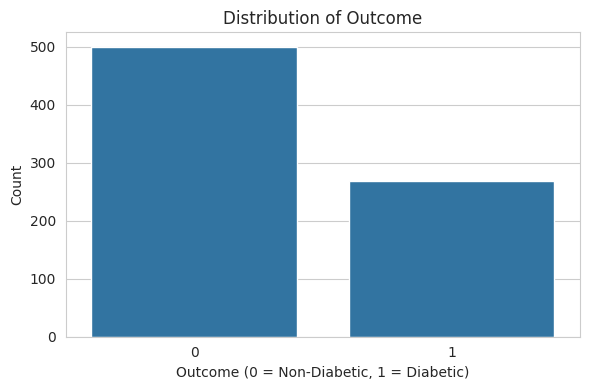

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x =target_column)
plt.title('Distribution of Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/target_distributions.png')

In [72]:
print("Mean Values by Outcome")
display(df.groupby(target_column).mean())

print("Median Values by Outcome")
display(df.groupby(target_column).median())

Mean Values by Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


Median Values by Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.0,107.5,72.0,29.0,125.0,30.40,0.336,27.0
1,4.0,140.0,74.0,29.0,125.0,34.25,0.449,36.0


In [73]:
distribution_summary = pd.DataFrame({
    "Skewness": df[feature_columns].skew(),
    "Kurtosis": df[feature_columns].kurtosis()
})

print("Skewness and Kurtosis")
display(distribution_summary)

Skewness and Kurtosis


,Skewness,Kurtosis
Pregnancies,0.901674,0.159220
Glucose,0.535587,-0.257847
BloodPressure,0.141885,1.098239
SkinThickness,0.837608,5.430987
Insulin,3.380019,16.232455
BMI,0.599233,0.920222
DiabetesPedigreeFunction,1.919911,5.594954
Age,1.129597,0.643159


Age Group vs Outcome


Outcome,0,1
AgeGroup,,
21-30,327,90
31-40,81,76
41-50,49,64
51-60,23,31
60+,20,7


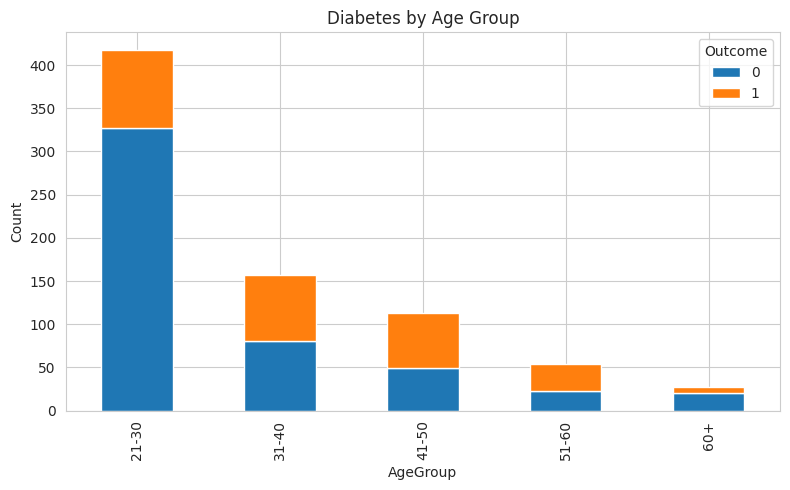

In [74]:
age_bins = [20, 30, 40, 50, 60, 100]
age_labels = [
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "60+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_outcome = pd.crosstab(
    df["AgeGroup"],
    df[target_column]
)

print("Age Group vs Outcome")
display(age_outcome)

age_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Diabetes by Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/age_group_analysis.png")
plt.show()

BMI Category vs Outcome


Outcome,0,1
BMICategory,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217


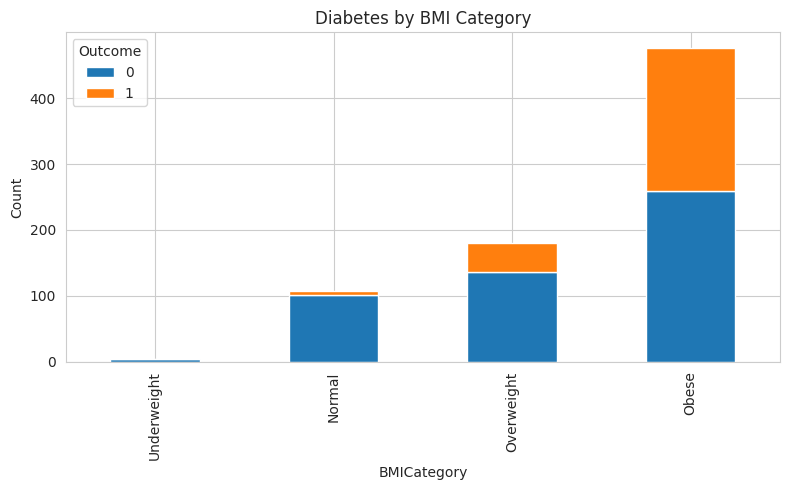

In [75]:
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = [
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
]

df["BMICategory"] = pd.cut(
    df["BMI"],
    bins=bmi_bins,
    labels=bmi_labels
)

bmi_outcome = pd.crosstab(
    df["BMICategory"],
    df[target_column]
)

print("BMI Category vs Outcome")
display(bmi_outcome)

bmi_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Diabetes by BMI Category")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/bmi_category_analysis.png")
plt.show()

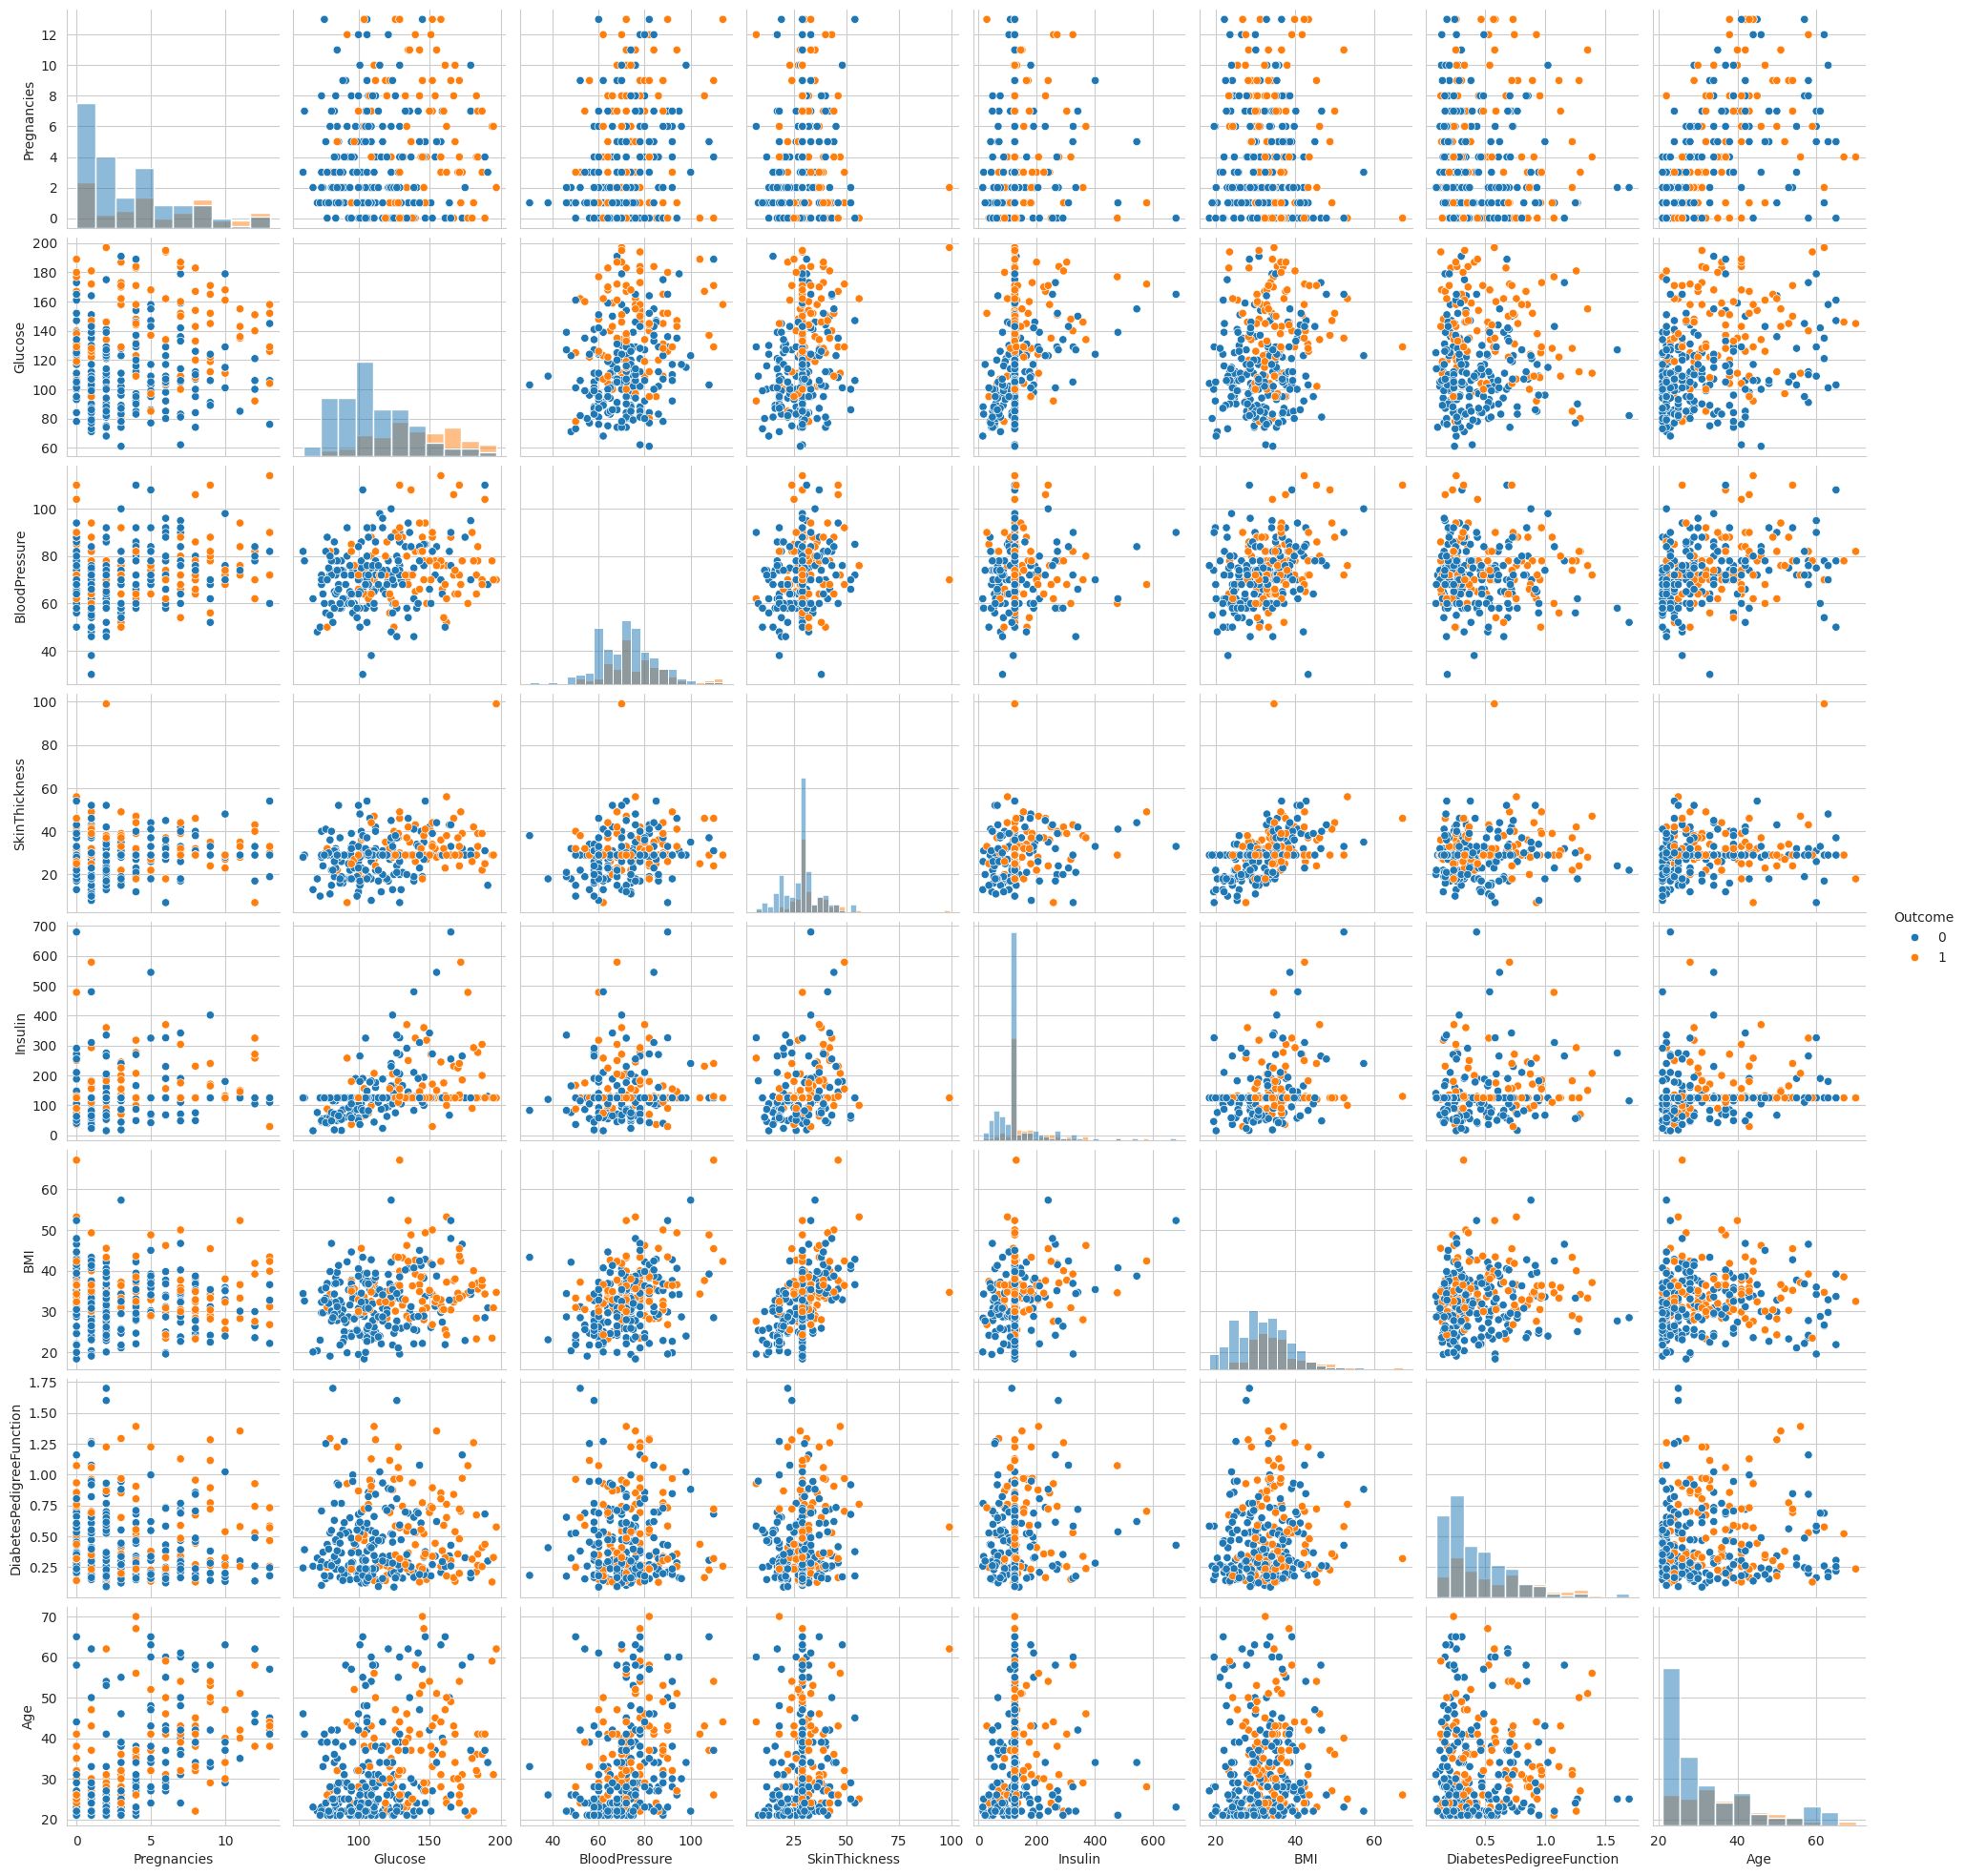

In [76]:
sample_df = df.sample(
    n=min(300, len(df)),
    random_state=42
)

pairplot = sns.pairplot(
    sample_df,
    hue=target_column,
    diag_kind="hist"
)

pairplot.savefig("../reports/figures/pairplot.png")
plt.show()

In [78]:
# ==========================================================
# 17. SAVE COMPREHENSIVE EDA SUMMARY
# ==========================================================

# Create EDA summary table
eda_summary = pd.DataFrame({
    "Feature": feature_columns,
    "CorrelationWithTarget": [
        correlation_matrix.loc[col, target_column]
        for col in feature_columns
    ],
    "OutlierCount": [
        count_outliers_iqr(df[col])
        for col in feature_columns
    ],
    "OutlierPercentage": [
        (count_outliers_iqr(df[col]) / len(df)) * 100
        for col in feature_columns
    ],
    "Skewness": [
        df[col].skew()
        for col in feature_columns
    ],
    "Kurtosis": [
        df[col].kurtosis()
        for col in feature_columns
    ],
    "Mean": [
        df[col].mean()
        for col in feature_columns
    ],
    "Median": [
        df[col].median()
        for col in feature_columns
    ],
    "StdDev": [
        df[col].std()
        for col in feature_columns
    ],
    "Min": [
        df[col].min()
        for col in feature_columns
    ],
    "Max": [
        df[col].max()
        for col in feature_columns
    ]
})

# Sort by absolute correlation with target
eda_summary = eda_summary.sort_values(
    by="CorrelationWithTarget",
    key=abs,
    ascending=False
).reset_index(drop=True)

# Round numerical columns
numeric_cols = eda_summary.select_dtypes(include="number").columns
eda_summary[numeric_cols] = eda_summary[numeric_cols].round(4)

# Display summary
print("Comprehensive EDA Summary")
display(eda_summary)

# Save to CSV
eda_summary.to_csv(
    "../reports/eda_summary.csv",
    index=False
)

print("EDA summary saved successfully.")
print("Saved to: ../reports/eda_summary.csv")

Comprehensive EDA Summary


,Feature,CorrelationWithTarget,OutlierCount,OutlierPercentage,Skewness,Kurtosis,Mean,Median,StdDev,Min,Max
0,Glucose,0.4928,0,0.0000,0.5356,-0.2578,121.6562,117.0000,30.4383,44.000,199.00
1,BMI,0.3120,8,1.0417,0.5992,0.9202,32.4552,32.3000,6.8752,18.200,67.10
2,Age,0.2384,9,1.1719,1.1296,0.6432,33.2409,29.0000,11.7602,21.000,81.00
3,Pregnancies,0.2219,4,0.5208,0.9017,0.1592,3.8451,3.0000,3.3696,0.000,17.00
4,SkinThickness,0.2149,87,11.3281,0.8376,5.4310,29.1081,29.0000,8.7912,7.000,99.00
5,Insulin,0.2038,346,45.0521,3.3800,16.2325,140.6719,125.0000,86.3831,14.000,846.00
6,DiabetesPedigreeFunction,0.1738,29,3.7760,1.9199,5.5950,0.4719,0.3725,0.3313,0.078,2.42
7,BloodPressure,0.1657,14,1.8229,0.1419,1.0982,72.3867,72.0000,12.0966,24.000,122.00


EDA summary saved successfully.
Saved to: ../reports/eda_summary.csv
